## 0. Setup

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAW_PATH  = r"D:\BUI THU HANG\Data Personal Project\Banking Transactions\Data\raw\Banking_Transactional_Dataset.xlsx"
SHEET     = "Banking Data"

FEE_COLS       = ["CreditCardFees", "InsuranceFees", "LatePaymentAmount"]
CUSTOMER_ATTRS = ["CustomerScore", "MonthlyIncome", "CustomerSegment", "RecommendedOffer"]

df = pd.read_excel(RAW_PATH, sheet_name=SHEET)
print(f"Shape: {df.shape[0]:,} dòng x {df.shape[1]} cột")

Shape: 20,000 dòng x 19 cột


## 1. Tổng quan schema và missing values            
Kiểu dữ liệu, cột thiếu nhiều, và cột có số giá trị phân biệt bất thường 

In [3]:
profile = pd.DataFrame({
    "dtype":     df.dtypes.astype(str),
    "n_null":    df.isna().sum(),
    "pct_null":  (df.isna().mean() * 100).round(2),
    "n_unique":  df.nunique(),
    "sample":    [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
profile

,dtype,n_null,pct_null,n_unique,sample
TransactionID,int64,0,0.00,20000,1
CustomerID,int64,0,0.00,8025,8270
TransactionDate,datetime64[us],0,0.00,871,2025-01-29 00:00:00
TransactionType,str,0,0.00,6,Card Payment
Amount,float64,0,0.00,19967,"6,980.19"
ProductCategory,str,0,0.00,5,Checking Account
ProductSubcategory,str,0,0.00,5,Gold
BranchCity,str,0,0.00,8,Seville
BranchLat,float64,0,0.00,8,37.39
BranchLong,float64,0,0.00,8,-5.98


- Bộ dữ liệu gồm 20.000 giao dịch ngân hàng với 19 biến và không có giá trị thiếu                        
- Mỗi giao dịch được định danh duy nhất bằng TransactionID, trong khi CustomerID cho thấy một khách hàng có thể thực hiện nhiều giao dịch                 
- Dữ liệu trải dài trên 871 ngày khác nhau, cho phép thực hiện các phân tích theo chuỗi thời gian         
- Bộ dữ liệu bao gồm đầy đủ thông tin về khách hàng, sản phẩm, chi nhánh và các loại phí, tạo điều kiện phân tích về giao dịch, phân khúc khách hàng và hiệu quả hoạt động của chi nhánh.

## 2. Xác thực `TransactionID` là khóa chính 
- Bản ghi trùng lặp hoàn toàn: Hai dòng dữ liệu giống hệt nhau, có thể phát sinh do lỗi nhập liệu hoặc ETL và có thể loại bỏ.
- Trùng TransactionID nhưng khác nội dung: Đây là dấu hiệu cho thấy cùng một mã giao dịch được gán cho nhiều bản ghi khác nhau, có thể lỗi từ hệ thống nguồn. Trường hợp này cần làm rõ thay vì xóa dữ liệu.

In [5]:
n_dup_id  = df["TransactionID"].duplicated().sum()
n_dup_row = df.duplicated().sum()

print(f"TransactionID trùng      : {n_dup_id:,}")
print(f"Dòng trùng hoàn toàn     : {n_dup_row:,}")
print(f"Số khách hàng (CustomerID): {df['CustomerID'].nunique():,}")
print(f"Số giao dịch / khách (TB) : {len(df) / df['CustomerID'].nunique():.1f}")

if n_dup_id:
    dup_ids = df.loc[df["TransactionID"].duplicated(keep=False), "TransactionID"].unique()[:3]
    display(df[df["TransactionID"].isin(dup_ids)].sort_values("TransactionID"))

TransactionID trùng      : 0
Dòng trùng hoàn toàn     : 0
Số khách hàng (CustomerID): 8,025
Số giao dịch / khách (TB) : 2.5


## 3. Kiểm tra tính nhất quán của đơn vị tiền tệ (`Currency`) 
Nếu bộ dữ liệu có nhiều loại tiền tệ, không cộng trực tiếp cột Amount.       
Cần kiểm tra và quy đổi về cùng một đơn vị tiền tệ trước khi tính toán.

In [6]:
cur = df["Currency"].value_counts(dropna=False)
print(cur, "\n")
if cur.shape[0] == 1:
    print(f"Bộ dữ liệu cùng sử dụng một loại tiền tệ ({cur.index[0]})")
else:
    print("Bộ dữ liệu chứa nhiều loại tiền tệ")
    display(df.groupby("Currency")["Amount"].agg(["count", "sum"]))

Currency
EUR    16974
USD     3026
Name: count, dtype: int64 

Bộ dữ liệu chứa nhiều loại tiền tệ


,count,sum
Currency,,
EUR,16974,"85,717,044.73"
USD,3026,"15,290,057.62"


## 4. Kiểm tra giá trị giao dịch (`Amount`)

Chiều của dòng tiền (tiền vào hay tiền ra) được xác định bởi TransactionType. Cần tạo thêm một cột như Direction (Inflow/Outflow) trước khi tính dòng tiền ròng (Net Cash Flow).

In [7]:
print("Thống kê Amount theo TransactionType:")
display(
    df.groupby("TransactionType")["Amount"]
      .agg(n="count", sum="sum", mean="mean", min="min", max="max")
      .sort_values("n", ascending=False)
)

Thống kê Amount theo TransactionType:


,n,sum,mean,min,max
TransactionType,,,,,
Withdrawal,3395,"17,050,205.57","5,022.15",13.00,"14,895.17"
Loan Payment,3369,"16,900,502.90","5,016.47",10.32,"14,882.64"
Card Payment,3345,"16,680,644.89","4,986.74",8.28,"14,851.93"
Fee,3308,"16,655,472.40","5,034.91",10.90,"14,892.06"
Transfer,3293,"16,895,091.22","5,130.61",11.60,"14,877.63"
Deposit,3290,"16,825,185.38","5,114.04",9.69,"14,786.16"


Deposit → Inflow             
Withdrawal → Outflow           
Card Payment → Outflow           
Fee → Outflow           
Loan Payment → Outflow           
Transfer không thể xác định là dòng tiền vào hay dòng tiền ra chỉ dựa trên TransactionType

## 5. Kiểm tra tính nhất quán của thông tin khách hàng `CustomerID` 
Xác minh mỗi CustomerID chỉ có một bộ thông tin khách hàng duy nhất. Nếu cùng một khách hàng có nhiều giá trị khác nhau cho CustomerScore, MonthlyIncome, CustomerSegment hoặc RecommendedOffer, cần xem xét nguyên nhân trước khi sử dụng phân tích.

In [8]:
g = df.groupby("CustomerID")[CUSTOMER_ATTRS].nunique()

stability = pd.DataFrame({
    "Number of Customer": (g > 1).sum(),
    "Sum": len(g),
})
stability["Pct"] = (stability["Number of Customer"] / stability["Sum"] * 100).round(2)
display(stability)

unstable_cols = stability.index[stability["Number of Customer"] > 0].tolist()
if unstable_cols:
    cid = g[(g[unstable_cols] > 1).any(axis=1)].index[0]
    print(f"\n EX — CustomerID {cid}:")
    display(df[df["CustomerID"] == cid][["CustomerID", "TransactionDate"] + CUSTOMER_ATTRS]
            .sort_values("TransactionDate"))
else:
    print("\n Verify that each customer has a single set of attributes")

,Number of Customer,Sum,Pct
CustomerScore,5841,8025,72.79
MonthlyIncome,5848,8025,72.87
CustomerSegment,4668,8025,58.17
RecommendedOffer,5350,8025,66.67



 EX — CustomerID 1001:


,CustomerID,TransactionDate,CustomerScore,MonthlyIncome,CustomerSegment,RecommendedOffer
5281,1001,2023-03-02,392,"3,622.06",Middle Income Segment,Personal Loan Cashback Offer
1454,1001,2023-08-11,393,"2,606.21",Low Income Segment,Financial Literacy Program Access
19073,1001,2024-03-28,647,"6,376.59",Middle Income Segment,Mid-tier Savings Booster
16009,1001,2024-12-12,414,"5,256.07",Middle Income Segment,Personal Loan Cashback Offer
1539,1001,2025-03-02,379,"1,544.21",Low Income Segment,Financial Literacy Program Access


Mỗi CustomerID chỉ có một bộ thông tin khách hàng (CustomerScore, MonthlyIncome, CustomerSegment và RecommendedOffer). Các thuộc tính này nhất quán trên tất cả các giao dịch, do đó có thể sử dụng trực tiếp để phân tích theo khách hàng hoặc xây dựng bảng thông tin khách hàng (Customer Dimension)

## 6. Mối quan hệ giữa `CustomerSegment` và `MonthlyIncome`
CustomerSegment có được tạo trực tiếp từ MonthlyIncome không?                  
Nếu có, thì hai cột này về bản chất phản ánh cùng một thông tin. Khi đó, không nên sử dụng cả hai để giải thích cho cùng một kết quả phân tích, vì sẽ dẫn đến lập luận mang tính lặp lại (circular reasoning). 

In [9]:
seg = (df.groupby("CustomerSegment")["MonthlyIncome"].agg(
          Count="count",Min_Income="min",Max_Income="max",Average_Income="mean").sort_values("Min_Income"))
display(seg)

# Các khoảng thu nhập có chồng lấn giữa các segment không?
bounds = seg[["Min_Income", "Max_Income"]].sort_values("Min_Income")
overlap = any(
    bounds["Min_Income"].iloc[i + 1] < bounds["Max_Income"].iloc[i]
    for i in range(len(bounds) - 1)
)
print("\nDo income ranges overlap across customer segments?", overlap)
if overlap:
    print("→ Income ranges overlap, suggesting CustomerSegment is not determined solely by MonthlyIncome.")
else:
    print("→ No overlap found, indicating CustomerSegment is likely derived directly from MonthlyIncome.")

,Count,Min_Income,Max_Income,Average_Income
CustomerSegment,,,,
Low Income Segment,4489,"1,000.86","2,999.98","2,005.81"
Middle Income Segment,8885,"3,000.15","6,999.93","4,987.61"
High Income Segment,6626,"7,002.08","9,998.88","8,508.90"



Do income ranges overlap across customer segments? False
→ No overlap found, indicating CustomerSegment is likely derived directly from MonthlyIncome.


CustomerSegment nhiều khả năng được xây dựng dựa trên MonthlyIncome. Do hai biến phản ánh cùng một thông tin, các phân tích tiếp theo chỉ sử dụng MonthlyIncome để tránh trùng lặp thông tin.

## 7. Xác minh ý nghĩa của các cột phí và khả năng đếm trùng

1. `TransactionType = 'Fee'` có bị đếm trùng với 3 cột phí không? (một lần ở `Amount`, một lần ở cột phí)
2. `LatePaymentAmount` là phí phạt trả chậm mà ngân hàng đã thu được (có thể tính vào doanh thu từ phí) hay số tiền khách hàng đang nợ quá hạn (không nên ghi nhận là doanh thu). Mô tả trong data dictionary hiện chưa đủ rõ để phân biệt hai trường hợp này.

In [10]:
df["_total_fees"] = df[FEE_COLS].fillna(0).sum(axis=1)

print("Distribution of each fee type (transactions > 0 only):")
for c in FEE_COLS:
    s = df.loc[df[c] > 0, c]
    print(f"  {c:20s} n={len(s):6,}  sum={s.sum():15,.0f}  mean={s.mean():10,.2f}  max={s.max():12,.2f}")

print("\nNumber of transactions with fees (>0) by TransactionType:")
display(pd.crosstab(df["TransactionType"], df["_total_fees"] > 0))

print("\nFee occurrence by ProductCategory:")
display(df.groupby("ProductCategory")[FEE_COLS].apply(lambda x: (x > 0).sum()))

Distribution of each fee type (transactions > 0 only):
  CreditCardFees       n= 4,082  sum=        104,398  mean=     25.58  max=       49.99
  InsuranceFees        n= 3,998  sum=        199,674  mean=     49.94  max=       99.95
  LatePaymentAmount    n= 3,369  sum=        333,088  mean=     98.87  max=      199.98

Number of transactions with fees (>0) by TransactionType:


_total_fees,False,True
TransactionType,,
Card Payment,1986,1359
Deposit,2014,1276
Fee,1938,1370
Loan Payment,0,3369
Transfer,1970,1323
Withdrawal,1986,1409



Fee occurrence by ProductCategory:


,CreditCardFees,InsuranceFees,LatePaymentAmount
ProductCategory,,,
Checking Account,0,0,711
Credit Card,4082,0,708
Loan,0,3998,635
Mortgage,0,0,644
Savings Account,0,0,671


- Các giá trị liên quan đến phí xuất hiện ở tất cả các loại giao dịch, chứ không chỉ ở những giao dịch có TransactionType = 'Fee'. Điều này cho thấy TransactionType = 'Fee' chỉ đại diện cho một loại giao dịch, không phải cho tất cả các khoản phí phát sinh.
- CreditCardFees và InsuranceFees thể hiện mối liên hệ rõ ràng với từng nhóm sản phẩm cụ thể, trong khi LatePaymentAmount lại xuất hiện ở tất cả các nhóm sản phẩm. 
- Dữ liệu hiện có không đủ để xác định LatePaymentAmount là khoản phí phạt trả chậm mà ngân hàng đã thu được hay là số dư nợ quá hạn của khách hàng. Vì vậy, không mặc định biến này là doanh thu từ phí.

In [11]:
# So sánh độ lớn LatePaymentAmount với Amount
late = df[df["LatePaymentAmount"] > 0].copy()
if len(late):
    late["Pct"] = late["LatePaymentAmount"] / late["Amount"]
    print(f"Number of LatePaymentAmount > 0: {len(late):,}\n")
    display(late[["Amount", "LatePaymentAmount", "Pct"]].describe())
else:
    print("No transactions have LatePaymentAmount > 0")

Number of LatePaymentAmount > 0: 3,369



,Amount,LatePaymentAmount,Pct
count,"3,369.00","3,369.00","3,369.00"
mean,"5,016.47",98.87,0.08
std,"3,515.51",58.50,0.40
min,10.32,0.01,0.00
25%,"2,235.69",47.76,0.01
50%,"4,347.30",98.11,0.02
75%,"7,268.68",149.94,0.04
max,"14,882.64",199.98,10.48


LatePaymentAmount nhìn chung nhỏ hơn nhiều so với giá trị giao dịch, với trung vị chỉ bằng 2% và trung bình bằng 8% của Amount. Tuy nhiên, một số giao dịch có LatePaymentAmount lớn hơn cả Amount (Pct > 1), cho thấy biến này khó có thể chỉ là một khoản phí của giao dịch. Thay vào đó, nó có thể đại diện cho số dư nợ quá hạn hoặc một khoản tài chính được ghi nhận độc lập.

## 8. Xác định mức độ chi tiết của dữ liệu chi nhánh
Dữ liệu không có BranchID. Nếu mỗi thành phố chỉ tương ứng với một tọa độ, thì không thể xác định từng chi nhánh riêng biệt. Vì vậy, mọi phân tích về "chi nhánh" thực chất chỉ phản ánh kết quả ở cấp thành phố, không phải ở cấp điểm giao dịch.

In [12]:
geo = df.groupby("BranchCity")[["BranchLat", "BranchLong"]].nunique()
multi = geo[(geo > 1).any(axis=1)]

print(f"Number of cities: {df['BranchCity'].nunique()}")
print(f"Cities with multiple coordinates: {len(multi)}\n")

display(df.groupby("BranchCity").agg(Transactions=("TransactionID", "count"),Customers=("CustomerID", "nunique"),Total_Amount=("Amount", "sum"))
      .sort_values("Transactions", ascending=False))

Number of cities: 8
Cities with multiple coordinates: 0



,Transactions,Customers,Total_Amount
BranchCity,,,
Barcelona,2564,2230,"13,033,624.54"
Murcia,2564,2218,"12,899,902.76"
Malaga,2524,2193,"12,917,492.75"
Seville,2513,2203,"12,673,128.30"
Zaragoza,2476,2156,"12,623,572.12"
Madrid,2472,2147,"12,181,857.62"
Bilbao,2455,2122,"12,219,141.95"
Valencia,2432,2148,"12,458,382.31"


## 9. Đánh giá phạm vi thời gian
Dữ liệu bao phủ 29 tháng liên tục (01/01/2023 – 20/05/2025), không có tháng nào bị thiếu. Tháng 05/2025 chỉ có dữ liệu đến ngày 20 (405 giao dịch so với mức trung bình 699 của các tháng khác) nên được coi là tháng chưa hoàn chỉnh và loại khỏi mọi phân tích xu hướng.

Start date: 2023-01-01
End date: 2025-05-20
Number of months: 29
Invalid date values: 0



,Transactions
TransactionDate,
2023-01,732
2023-02,614
2023-03,681
2023-04,698
2023-05,688
2023-06,707
2023-07,704
2023-08,706
2023-09,693


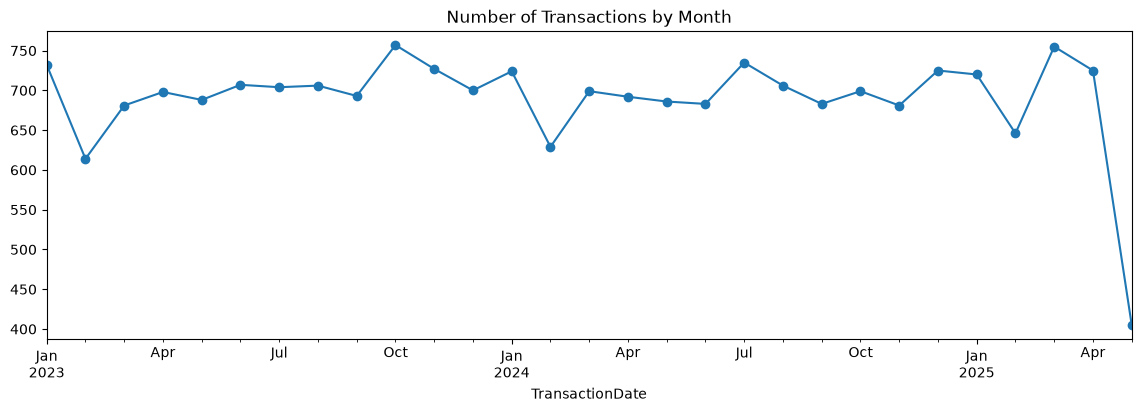

In [13]:
d = pd.to_datetime(df["TransactionDate"], errors="coerce")
print(f"Start date: {d.min().date()}")
print(f"End date: {d.max().date()}")
print(f"Number of months: {d.dt.to_period('M').nunique()}")
print(f"Invalid date values: {d.isna().sum() - df['TransactionDate'].isna().sum():,}\n")
monthly = d.dt.to_period("M").value_counts().sort_index()
display(monthly.to_frame("Transactions"))
monthly.plot(kind="line", figsize=(14, 4), marker="o",title="Number of Transactions by Month");

## 10. Kiểm tra tính nhất quán của các giá trị phân loại
Kiểm tra tính nhất quán của các biến phân loại và phát hiện những giá trị cần được chuẩn hóa trong tầng staging, như khác biệt về chữ hoa/chữ thường, khoảng trắng thừa hoặc các cách viết khác nhau nhưng cùng mang một ý nghĩa

In [14]:
cat_cols = ["TransactionType", "ProductCategory", "ProductSubcategory",
            "Channel", "Currency", "CustomerSegment", "RecommendedOffer"]

for c in cat_cols:
    vals = df[c].dropna().unique()
    print(f"\n=== {c} ({len(vals)} giá trị) ===")
    for v in sorted(vals.tolist()):
        flag = ""
        if isinstance(v, str):
            if v != v.strip():      flag += "=> có khoảng trắng thừa"
            if v != v.strip().title() and v != v.strip().upper(): flag += "=> kiểu chữ không đồng nhất"
        print(f"   {v!r}{flag}")


=== TransactionType (6 giá trị) ===
   'Card Payment'
   'Deposit'
   'Fee'
   'Loan Payment'
   'Transfer'
   'Withdrawal'

=== ProductCategory (5 giá trị) ===
   'Checking Account'
   'Credit Card'
   'Loan'
   'Mortgage'
   'Savings Account'

=== ProductSubcategory (5 giá trị) ===
   'Business'
   'Gold'
   'Platinum'
   'Standard'
   'Student'

=== Channel (4 giá trị) ===
   'ATM'
   'Branch'
   'Mobile'
   'Online'

=== Currency (2 giá trị) ===
   'EUR'
   'USD'

=== CustomerSegment (3 giá trị) ===
   'High Income Segment'
   'Low Income Segment'
   'Middle Income Segment'

=== RecommendedOffer (7 giá trị) ===
   'Exclusive Platinum Package'
   'Financial Literacy Program Access'
   'Gold Card with Travel Benefits'=> kiểu chữ không đồng nhất
   'Mid-tier Savings Booster'=> kiểu chữ không đồng nhất
   'No-Fee Basic Account'
   'Personal Loan Cashback Offer'
   'Premium Investment Services'


Hầu hết các biến phân loại đều có tập giá trị nhỏ, rõ ràng và không phát hiện các vấn đề như lỗi chính tả, khác biệt về chữ hoa/chữ thường hoặc các nhãn trùng lặp. Tuy nhiên, cột RecommendedOffer có ít nhất một giá trị sử dụng kiểu chữ không nhất quán (Mid-tier Savings Booster), cho thấy cột này cần được chuẩn hóa ở tầng staging nhằm đảm bảo tính nhất quán cho việc báo cáo và phân tích.

## 11. Đánh giá khả năng phân tích hiệu quả của các đề xuất sản phẩm
Cột RecommendedOffer chỉ ghi nhận sản phẩm hoặc dịch vụ được đề xuất, nhưng không có trường nào cho biết khách hàng có chấp nhận, từ chối hay thực hiện đăng ký. Vì vậy, dữ liệu chỉ cho phép phân tích mức độ và phân bố của các đề xuất, không thể đánh giá tỷ lệ chuyển đổi hoặc hiệu quả của từng loại đề xuất.

In [15]:
print("Số offer khác nhau:", df["RecommendedOffer"].nunique(), "\n")
display(pd.crosstab(df["RecommendedOffer"], df["CustomerSegment"]))

print("\n Số offer khác nhau của mỗi khách")
display(df.groupby("CustomerID")["RecommendedOffer"].nunique().value_counts().to_frame("so_khach"))

Số offer khác nhau: 7 



CustomerSegment,High Income Segment,Low Income Segment,Middle Income Segment
RecommendedOffer,,,
Exclusive Platinum Package,2672,0,0
Financial Literacy Program Access,0,3540,0
Gold Card with Travel Benefits,0,0,1837
Mid-tier Savings Booster,0,0,5220
No-Fee Basic Account,0,949,0
Personal Loan Cashback Offer,0,0,1828
Premium Investment Services,3954,0,0



 Số offer khác nhau của mỗi khách


,so_khach
RecommendedOffer,
2,2981
1,2675
3,1664
4,580
5,114
6,11


Mỗi loại RecommendedOffer chỉ xuất hiện trong một phân khúc khách hàng, cho thấy mối liên hệ chặt chẽ giữa RecommendedOffer và CustomerSegment. Đồng thời, một khách hàng có thể nhận nhiều đề xuất khác nhau, cho thấy các đề xuất có thể thay đổi theo từng giao dịch hoặc theo thời gian.

## 12. Bảng quyết định

| No. | Vấn đề | Phát hiện | Quyết định xử lý |
|---:|--------|-----------|------------------|
| **1** | `TransactionID` trùng | Không phát hiện `TransactionID` trùng lặp. | Giữ nguyên, không xử lý. |
| **2** | Đa tiền tệ | Dữ liệu gồm nhiều loại tiền tệ (`Currency`) nhưng không có tỷ giá quy đổi. | Không cộng trực tiếp `Amount` giữa các loại tiền tệ. Chỉ phân tích theo từng `Currency`. |
| **3** | Xác định inflow / outflow | Deposit → Inflow; Withdrawal, Card Payment, Fee, Loan Payment → Outflow; Transfer không thể xác định chiều dòng tiền chỉ dựa trên `TransactionType`. | Tạo cột `CashFlowDirection`; gán `Transfer = Unknown` và loại khỏi các phân tích yêu cầu xác định dòng tiền vào/ra. |
| **4** | Thuộc tính khách hàng không ổn định | Một số thuộc tính khách hàng thay đổi theo thời gian (`MonthlyIncome`, `CustomerScore`, `RecommendedOffer`). | Không coi các cột này là thuộc tính tĩnh của khách hàng; giữ ở cấp giao dịch hoặc sử dụng giá trị mới nhất khi xây dựng bảng khách hàng. |
| **5** | `CustomerSegment` và `MonthlyIncome` | `CustomerSegment` được suy ra trực tiếp từ `MonthlyIncome` (không có khoảng thu nhập chồng lấn). | Chỉ sử dụng `MonthlyIncome` trong các phân tích tiếp theo để tránh trùng lặp thông tin. |
| **6** | Đếm trùng phí và ý nghĩa của `LatePaymentAmount` | Các khoản phí xuất hiện ở nhiều loại giao dịch; chưa đủ cơ sở xác định `LatePaymentAmount` là phí đã thu hay khoản nợ quá hạn. | Không mặc định tính `LatePaymentAmount` vào doanh thu từ phí. |
| **7** | Mức độ chi tiết của dữ liệu chi nhánh | Không có `BranchID`; mỗi thành phố chỉ tương ứng với một cặp tọa độ. | Thực hiện các phân tích ở **cấp thành phố (`BranchCity`)**. |
| **8** | Phạm vi kết luận theo thời gian | Dữ liệu bao phủ **29 tháng** (01/2023–05/2025); tháng 05/2025  chưa hoàn chỉnh. | Phân tích xu hướng và mùa vụ sau khi loại bỏ tháng 05/2025 khỏi phân tích chuỗi thời gian. |

### Hạn chế của dữ liệu 
- Không có AccountID hoặc số dư tài khoản → không thể phân tích ở cấp tài khoản hoặc tính số dư theo thời gian.
- Không có ngày mở tài khoản → không thể thực hiện cohort analysis hoặc churn analysis.
TransactionDate chỉ có ngày, không có thời gian trong ngày → không thể phân tích hành vi theo giờ.
- Không có thông tin khách hàng chấp nhận hoặc chuyển đổi từ RecommendedOffer → chỉ phân tích được mô hình phân bổ đề xuất, không đánh giá được hiệu quả recommendation.
- Transfer không thể xác định là dòng tiền vào hay dòng tiền ra chỉ từ TransactionType.
- CustomerSegment được xây dựng từ MonthlyIncome; hai biến mang thông tin trùng lặp nên không sử dụng đồng thời trong cùng một phân tích.
- LatePaymentAmount có ý nghĩa chưa rõ (phí đã thu hay dư nợ quá hạn), vì vậy không được mặc định coi là doanh thu từ phí.
- Dữ liệu chứa nhiều loại tiền tệ nhưng không có tỷ giá quy đổi, nên các chỉ tiêu về giá trị tiền tệ chỉ được so sánh trong cùng một loại tiền tệ hoặc sau khi được quy đổi.
- Không có BranchID; mọi phân tích về chi nhánh được thực hiện ở cấp thành phố (BranchCity), không phải cấp điểm giao dịch.

In [16]:
# Tạo bảng profiling
profile = pd.DataFrame({
    "Column": df.columns, "Data Type": df.dtypes.astype(str).values, "Non-Null": df.notna().sum().values,
    "Missing": df.isna().sum().values, "Missing (%)": (df.isna().mean() * 100).round(2).values,
    "Unique": df.nunique().values, "Example Value": df.iloc[0].values})
display(profile)

,Column,Data Type,Non-Null,Missing,Missing (%),Unique,Example Value
0,TransactionID,int64,20000,0,0.00,20000,1
1,CustomerID,int64,20000,0,0.00,8025,8270
2,TransactionDate,datetime64[us],20000,0,0.00,871,2025-01-29 00:00:00
3,TransactionType,str,20000,0,0.00,6,Card Payment
4,Amount,float64,20000,0,0.00,19967,"6,980.19"
5,ProductCategory,str,20000,0,0.00,5,Checking Account
6,ProductSubcategory,str,20000,0,0.00,5,Gold
7,BranchCity,str,20000,0,0.00,8,Seville
8,BranchLat,float64,20000,0,0.00,8,37.39
9,BranchLong,float64,20000,0,0.00,8,-5.98


In [17]:
# Xuất báo cáo profiling
profile.to_csv("../Reports/01_profiling_schema.csv", index=False,encoding="utf-8-sig")
print("Saved: reports/01_profiling_schema.csv")

Saved: reports/01_profiling_schema.csv
